In [20]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Baseline model: logistic regressor

In [21]:
df = pd.read_parquet('/content/drive/MyDrive/SB/SB_Project/classification_ring/data/processed/data_ml.parquet')
df.head()

,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,1u9c,A,172,,S,H,0.354,-1.001,-0.749,-0.228,...,-0.912,17.0,R,1,0,0,0,0,0,1
1,1u9c,A,184,,G,-,0.250,-2.102,-3.018,-0.384,...,-1.853,19.0,T,1,0,0,0,0,0,0
2,1u9c,A,10,,T,-,0.000,-1.252,2.751,-0.032,...,-3.242,12.0,M,1,0,0,0,0,0,0
3,1u9c,A,133,,V,T,0.021,-1.076,-0.664,-1.337,...,1.313,15.0,P,0,0,0,0,0,0,1
4,1u9c,A,146,,G,T,0.548,1.315,0.127,-0.384,...,2.064,6.0,G,1,0,0,0,0,0,0


#### Split train/test/validation by pdb_id

In [22]:
print(df.columns.tolist())
print(df.dtypes)
#looking at the column names

['pdb_id', 's_ch', 's_resi', 's_ins', 's_resn', 's_ss8', 's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5', 's_3di_state', 's_3di_letter', 't_ch', 't_resi', 't_ins', 't_resn', 't_ss8', 't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5', 't_3di_state', 't_3di_letter', 'HBOND', 'IONIC', 'PICATION', 'PIHBOND', 'PIPISTACK', 'SSBOND', 'VDW']
pdb_id           object
s_ch             object
s_resi            int64
s_ins            object
s_resn           object
s_ss8            object
s_rsa           float64
s_phi           float64
s_psi           float64
s_a1            float64
s_a2            float64
s_a3            float64
s_a4            float64
s_a5            float64
s_3di_state     float64
s_3di_letter     object
t_ch             object
t_resi            int64
t_ins            object
t_resn           object
t_ss8            object
t_rsa           float64
t_phi           float64
t_psi           float64
t_a1            float64
t_a2            float64
t_a3  

Defining the columns

In [23]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

#Numerical features
num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

#Categorical features
cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]

print("Label distribution:")
print(df[label_cols].sum().sort_values(ascending=False))

Label distribution:
HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


Spliting

In [24]:
#avoiding data leakage
pdb_ids = df['pdb_id'].unique()
print(f"Total unique PDBs: {len(pdb_ids)}")

#using 70% train, 15% val, 15% test
train_pdbs, temp_pdbs = train_test_split(pdb_ids, test_size=0.30, random_state=42)
val_pdbs, test_pdbs   = train_test_split(temp_pdbs, test_size=0.50, random_state=42)

train_df = df[df['pdb_id'].isin(train_pdbs)].reset_index(drop=True)
val_df   = df[df['pdb_id'].isin(val_pdbs)].reset_index(drop=True)
test_df  = df[df['pdb_id'].isin(test_pdbs)].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, {len(train_pdbs)} PDBs")
print(f"Val:   {len(val_df)} rows, {len(val_pdbs)} PDBs")
print(f"Test:  {len(test_df)} rows, {len(test_pdbs)} PDBs")

Total unique PDBs: 3827
Train: 999083 rows, 2678 PDBs
Val:   238810 rows, 574 PDBs
Test:  214518 rows, 575 PDBs


Preparation of X and Y

In [25]:
feature_cols = num_features + cat_features

X_train = train_df[feature_cols]
Y_train = train_df[label_cols]

X_val = val_df[feature_cols]
Y_val = val_df[label_cols]

X_test = test_df[feature_cols]
Y_test = test_df[label_cols]

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (999083, 22)
Y_train shape: (999083, 7)


Preproccessing to clean the features

In [26]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.impute import SimpleImputer
#Imputing was necessary because we of NaN vaues
# Numerical:impute with median then scale
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical:impute with most frequent,then encode
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

lr_model = MultiOutputClassifier(
    LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', lr_model)
])

print("Pipeline built successfully")

Pipeline built successfully


Train

In [27]:
print("Training")
pipeline.fit(X_train, Y_train)
print("Training complete!")

Training
Training complete!


Evaluation of validation set

In [28]:
from sklearn.metrics import classification_report, f1_score
import numpy as np
Y_pred = pipeline.predict(X_val)

print("=" * 60)
print("For each Class Results on VALIDATION SET")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))
macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")

For each Class Results on VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.39      0.59      0.47     65125
     present       0.81      0.65      0.72    173685

    accuracy                           0.64    238810
   macro avg       0.60      0.62      0.60    238810
weighted avg       0.69      0.64      0.65    238810


--- VDW ---
              precision    recall  f1-score   support

      absent       0.56      0.58      0.57    117837
     present       0.57      0.55      0.56    120973

    accuracy                           0.56    238810
   macro avg       0.56      0.56      0.56    238810
weighted avg       0.57      0.56      0.56    238810


--- IONIC ---
              precision    recall  f1-score   support

      absent       1.00      0.90      0.94    233328
     present       0.18      0.99      0.31      5482

    accuracy                           0.90    238810
   macro avg       0.59      0.94      0.63 

Test Imbalance

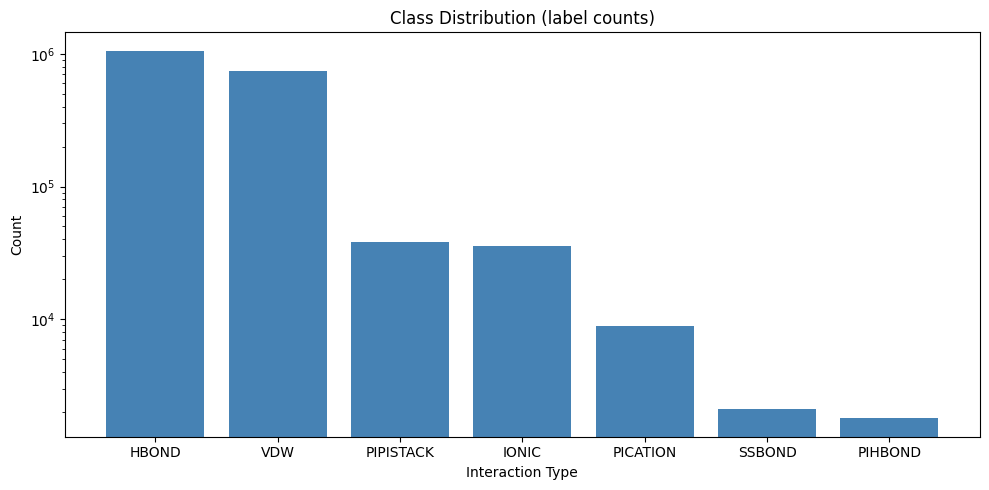

HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


In [29]:
import matplotlib.pyplot as plt

label_counts = df[label_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue')
plt.title("Class Distribution (label counts)")
plt.ylabel("Count")
plt.xlabel("Interaction Type")
plt.yscale('log')#seeing log scale because very imbalanced
plt.tight_layout()
plt.show()

print(label_counts)

Saving test for later

In [30]:
os.makedirs("classification_ring/data/processed", exist_ok=True)

train_df.to_parquet("classification_ring/data/processed/train.parquet", index=False)
val_df.to_parquet("classification_ring/data/processed/val.parquet", index=False)
test_df.to_parquet("classification_ring/data/processed/test.parquet", index=False)

print("Splits saved successfully.")
print("DO NOT touch test.parquet until final evaluation pliz!")

Splits saved successfully.
DO NOT touch test.parquet until final evaluation!
